  <a href="https://colab.research.google.com/github/marcpalo1999/MIA_sanidad/blob/main/2_1.1_Solucion_Ejercicios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  ## SOLUCIONES - Ejercicios Capítulo 6: Valores Nulos

In [1]:
# SOLUCIÓN EJERCICIO 1
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Cargar el dataset
df = pd.read_csv("./data/heart_disease_dataset_con_nulos.csv")


  ### Ejercicio 1



  Detecta y analiza valores nulos:



  1. Cuenta cuántos valores nulos hay en total en el dataset



  2. Identifica qué columnas tienen valores nulos



  3. Calcula qué porcentaje del dataset representan los valores nulos

In [2]:
# SOLUCIÓN EJERCICIO 1

# 1. Total de valores nulos en el dataset
total_nulos = df.isnull().sum().sum()

# 2. Valores nulos por columna
nulos_por_columna = df.isnull().sum()
# Filtrar solo columnas con nulos: nulos_por_columna[nulos_por_columna > 0]

# 3. Porcentaje de valores nulos
porcentaje_nulos_total = (total_nulos / (df.shape[0] * df.shape[1])) * 100
porcentaje_por_columna = (df.isnull().sum() / len(df)) * 100

# Mostrar solo columnas con nulos
columnas_con_nulos = porcentaje_por_columna[porcentaje_por_columna > 0]

nulos_por_columna



age                        0
sex                        0
cp                         0
trestbps                   0
chol                       0
fbs                        0
restecg                    0
thalach                    0
exang                      0
oldpeak                    0
slope                     15
ca                        19
thal                      17
num                       16
edad_en_meses              0
indice_colesterol_edad     0
grupo_edad                 0
categoria_colesterol       0
sexo_texto                 0
nivel_enfermedad           0
dtype: int64

  ### Ejercicio 2



  Si encuentras valores nulos, practica diferentes estrategias:



  1. Crea una copia del dataset llamada `df_test`



  2. Para cualquier columna numérica con nulos, rellénalos con la mediana



  3. Para cualquier columna categórica con nulos, rellénalos con "Desconocido"

In [3]:
# SOLUCIÓN EJERCICIO 2

# 1. Crear copia del dataset
df_test = df.copy()

# 2. Rellenar columnas numéricas con mediana
# Identificar columnas numéricas con nulos
columnas_numericas = df_test.select_dtypes(include=[np.number]).columns
for columna in columnas_numericas:
    if df_test[columna].isnull().sum() > 0:
        mediana = df_test[columna].median()
        df_test[columna] = df_test[columna].fillna(mediana)

# 3. Rellenar columnas categóricas con "Desconocido"
# Identificar columnas categóricas (object) con nulos
columnas_categoricas = df_test.select_dtypes(include=['object']).columns
for columna in columnas_categoricas:
    if df_test[columna].isnull().sum() > 0:
        df_test[columna] = df_test[columna].fillna("Desconocido")

# Verificar que no quedan nulos
df_test.isnull().sum()

# Métodos alternativos para rellenar:
# df_test.fillna(df_test.median(), inplace=True)  # Solo numéricas
# df_test.fillna("Desconocido", inplace=True)     # Todas las columnas
# df_test.fillna(method='forward')                # Propagación hacia adelante



age                       0
sex                       0
cp                        0
trestbps                  0
chol                      0
fbs                       0
restecg                   0
thalach                   0
exang                     0
oldpeak                   0
slope                     0
ca                        0
thal                      0
num                       0
edad_en_meses             0
indice_colesterol_edad    0
grupo_edad                0
categoria_colesterol      0
sexo_texto                0
nivel_enfermedad          0
dtype: int64

  ## SOLUCIONES - Ejercicios Capítulo 7: Exploración de Datos

  ### Ejercicio 1



  Explora la distribución de variables:



  1. Cuenta los valores únicos de la variable `cp` (tipo de dolor)



  2. Calcula qué porcentaje de pacientes tiene cada tipo de dolor



  3. Encuentra la edad promedio por tipo de dolor

In [4]:
# SOLUCIÓN EJERCICIO 1

# 1. Frecuencia de cada tipo de dolor en pecho
conteo_dolor = df["cp"].value_counts().sort_index()

# 2. Porcentajes de cada tipo de dolor
porcentaje_dolor = (df["cp"].value_counts(normalize=True) * 100).round(1).sort_index()

# 3. Edad promedio por tipo de dolor
edad_por_tipo_dolor = df.groupby("cp")["age"].mean().round(1)

# Mostrar resultados combinados
resultado_dolor = pd.DataFrame({
    'Conteo': conteo_dolor,
    'Porcentaje': porcentaje_dolor,
    'Edad_Promedio': edad_por_tipo_dolor
})

resultado_dolor

# Método alternativo con crosstab para más estadísticas:
# pd.crosstab(df["cp"], columns="count", margins=True)



,Conteo,Porcentaje,Edad_Promedio
cp,,,
1,23,7.6,55.9
2,50,16.5,51.4
3,86,28.4,53.7
4,144,47.5,55.7


  ### Ejercicio 2



  Crea tablas cruzadas:



  1. Crea una tabla cruzada entre `grupo_edad` y `tiene_enfermedad`



  2. Convierte esta tabla a porcentajes por columna para ver qué grupo de edad tiene más riesgo



  3. Calcula el colesterol promedio por grupo de edad

In [5]:
# SOLUCIÓN EJERCICIO 2

# Primero necesitamos crear las variables que usaremos (del capítulo anterior)
df["grupo_edad"] = pd.cut(df["age"], 
                          bins=[0, 40, 50, 60, 70, 100],
                          labels=["<40", "40-49", "50-59", "60-69", "70+"])

df["tiene_enfermedad"] = np.where(df["num"] > 0, "Sí", "No")

# 1. Tabla cruzada entre grupo de edad y enfermedad
tabla_edad_enfermedad = pd.crosstab(df["grupo_edad"], df["tiene_enfermedad"])

# 2. Porcentajes por columna (qué porcentaje de cada grupo de edad tiene enfermedad)
porcentajes_por_fila = pd.crosstab(df["grupo_edad"], df["tiene_enfermedad"], 
                                   normalize='index') * 100

# 3. Colesterol promedio por grupo de edad
colesterol_por_edad = df.groupby("grupo_edad")["chol"].mean().round(1)

tabla_edad_enfermedad

porcentajes_por_fila

colesterol_por_edad



/var/folders/hj/z81bpvv52rxg939nrr4_8qp00000gn/T/ipykernel_27699/1030979913.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  colesterol_por_edad = df.groupby("grupo_edad")["chol"].mean().round(1)


grupo_edad
<40      215.0
40-49    236.6
50-59    248.8
60-69    261.2
70+      247.7
Name: chol, dtype: float64

  ### Ejercicio 3



  Análisis de riesgo:



  1. Crea una variable `colesterol_alto` que sea "Sí" si `chol` > 240, "No" en caso contrario



  2. Crea una tabla cruzada entre `colesterol_alto` y `tiene_enfermedad`



  3. Calcula qué porcentaje de personas con colesterol alto tiene enfermedad cardíaca

In [6]:
# SOLUCIÓN EJERCICIO 3

# 1. Variable binaria para colesterol alto
df["colesterol_alto"] = np.where(df["chol"] > 240, "Sí", "No")

# 2. Tabla cruzada colesterol vs enfermedad
tabla_colesterol_enfermedad = pd.crosstab(df["colesterol_alto"], df["tiene_enfermedad"])

# 3. Porcentaje de personas con colesterol alto que tiene enfermedad
porcentajes_colesterol = pd.crosstab(df["colesterol_alto"], df["tiene_enfermedad"], 
                                     normalize='index') * 100

tabla_colesterol_enfermedad

porcentajes_colesterol

# Análisis: De las personas con colesterol alto, X% tiene enfermedad cardíaca
# vs Y% de las personas con colesterol normal

# Método alternativo para calcular el porcentaje específico:
# personas_colesterol_alto = df[df["colesterol_alto"] == "Sí"]
# porcentaje_enfermos_colesterol_alto = (personas_colesterol_alto["tiene_enfermedad"] == "Sí").mean() * 100



tiene_enfermedad,No,Sí
colesterol_alto,,
No,61.589404,38.410596
Sí,48.684211,51.315789


  ## SOLUCIONES - Ejercicios Capítulo 8: Visualización

  ### Ejercicio 1



  Crea visualizaciones básicas:



  1. Haz un histograma de la presión arterial (`trestbps`)



  2. Crea un gráfico de barras de la variable `categoria_colesterol`



  3. Haz un box plot del colesterol por grupo de edad

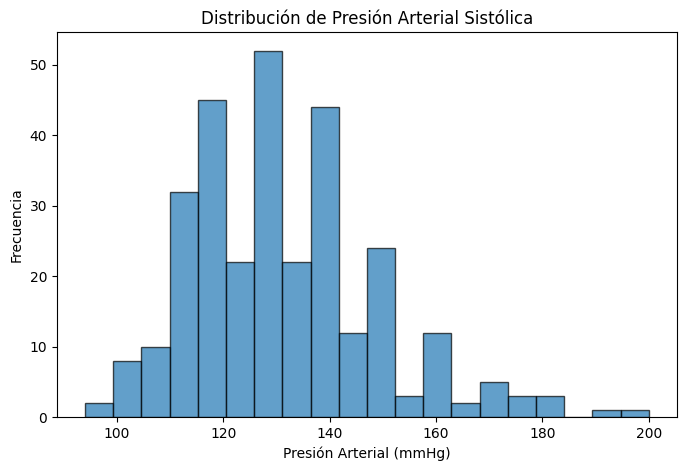

In [7]:
# SOLUCIÓN EJERCICIO 1

# 1. Histograma de presión arterial
plt.figure(figsize=(8, 5))
df["trestbps"].plot(kind='hist', bins=20, edgecolor='black', alpha=0.7)
plt.title("Distribución de Presión Arterial Sistólica")
plt.xlabel("Presión Arterial (mmHg)")
plt.ylabel("Frecuencia")
plt.show()



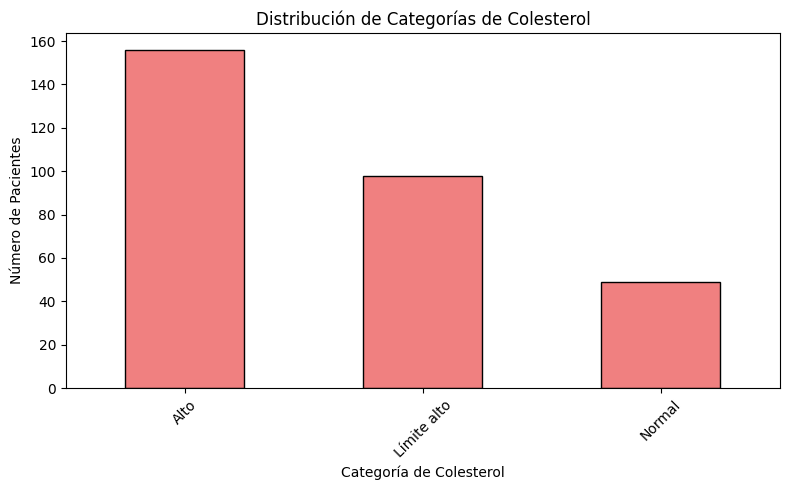

In [8]:
# 2. Gráfico de barras para categorías de colesterol
# Primero crear la variable si no existe
def clasificar_colesterol(valor):
    if pd.isna(valor):
        return "Desconocido"
    elif valor < 200:
        return "Normal"
    elif valor < 240:
        return "Límite alto"
    else:
        return "Alto"

df["categoria_colesterol"] = df["chol"].apply(clasificar_colesterol)

plt.figure(figsize=(8, 5))
df["categoria_colesterol"].value_counts().plot(kind='bar', color='lightcoral', edgecolor='black')
plt.title("Distribución de Categorías de Colesterol")
plt.xlabel("Categoría de Colesterol")
plt.ylabel("Número de Pacientes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



<Figure size 1000x600 with 0 Axes>

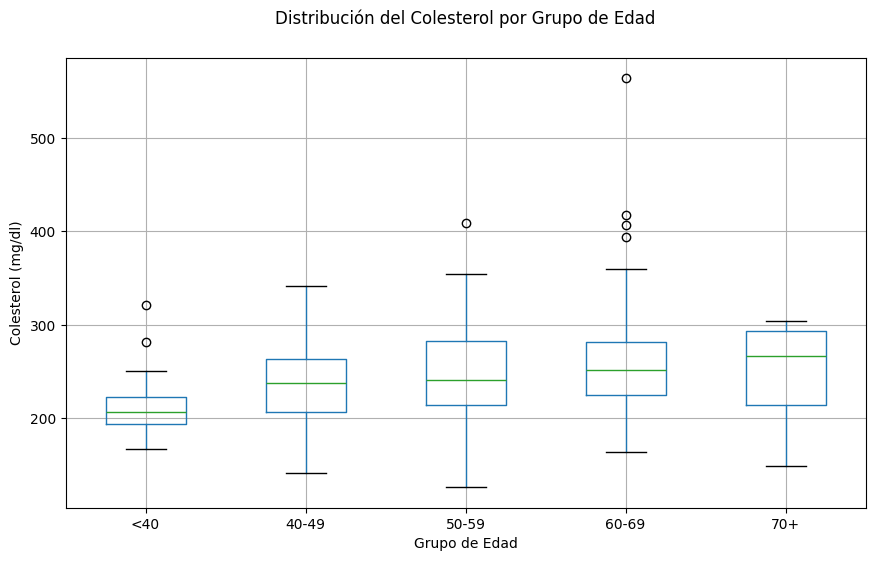

In [9]:
# 3. Box plot del colesterol por grupo de edad
plt.figure(figsize=(10, 6))
df.boxplot(column='chol', by='grupo_edad', figsize=(10, 6))
plt.suptitle('Distribución del Colesterol por Grupo de Edad')
plt.title("")  # Quitar título automático
plt.xlabel('Grupo de Edad')
plt.ylabel('Colesterol (mg/dl)')
plt.show()



  ### Ejercicio 2



  Explora relaciones entre variables:



  1. Crea un scatter plot entre `age` y `thalach` (frecuencia cardíaca máxima)



  2. Haz un histograma comparativo de `thalach` para pacientes con y sin enfermedad



  3. Crea un gráfico de barras que compare el porcentaje de enfermedad por sexo

<Figure size 800x600 with 0 Axes>

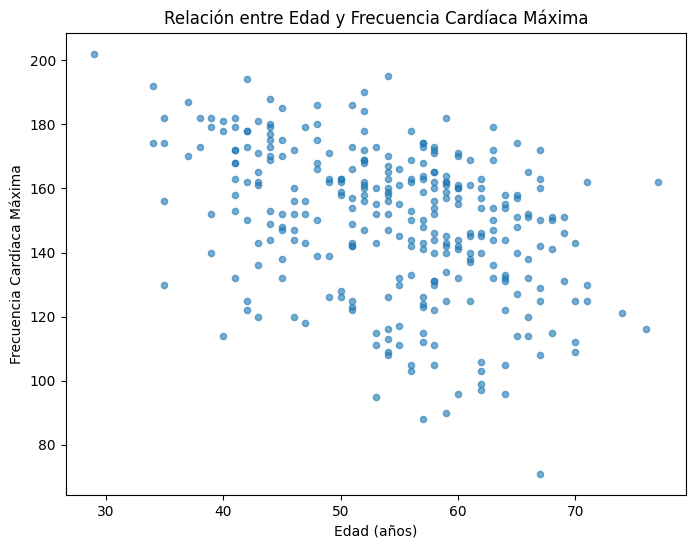

In [10]:
# SOLUCIÓN EJERCICIO 2

# 1. Scatter plot edad vs frecuencia cardíaca máxima
plt.figure(figsize=(8, 6))
df.plot(kind='scatter', x='age', y='thalach', alpha=0.6, figsize=(8, 6))
plt.title("Relación entre Edad y Frecuencia Cardíaca Máxima")
plt.xlabel("Edad (años)")
plt.ylabel("Frecuencia Cardíaca Máxima")
plt.show()



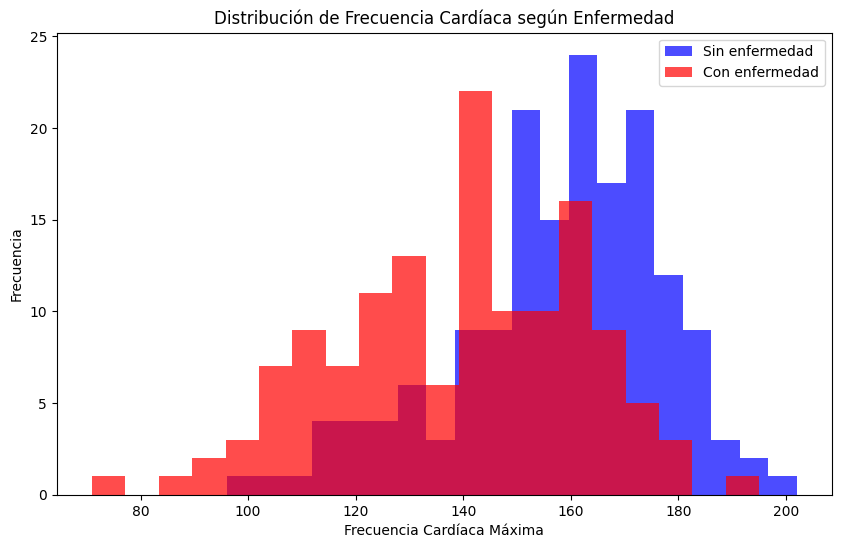

In [11]:
# 2. Histograma comparativo de frecuencia cardíaca por enfermedad
plt.figure(figsize=(10, 6))
df[df["tiene_enfermedad"] == "No"]["thalach"].plot(kind='hist', alpha=0.7, 
                                                   label='Sin enfermedad', bins=20, color='blue')
df[df["tiene_enfermedad"] == "Sí"]["thalach"].plot(kind='hist', alpha=0.7, 
                                                   label='Con enfermedad', bins=20, color='red')
plt.title("Distribución de Frecuencia Cardíaca según Enfermedad")
plt.xlabel("Frecuencia Cardíaca Máxima")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()



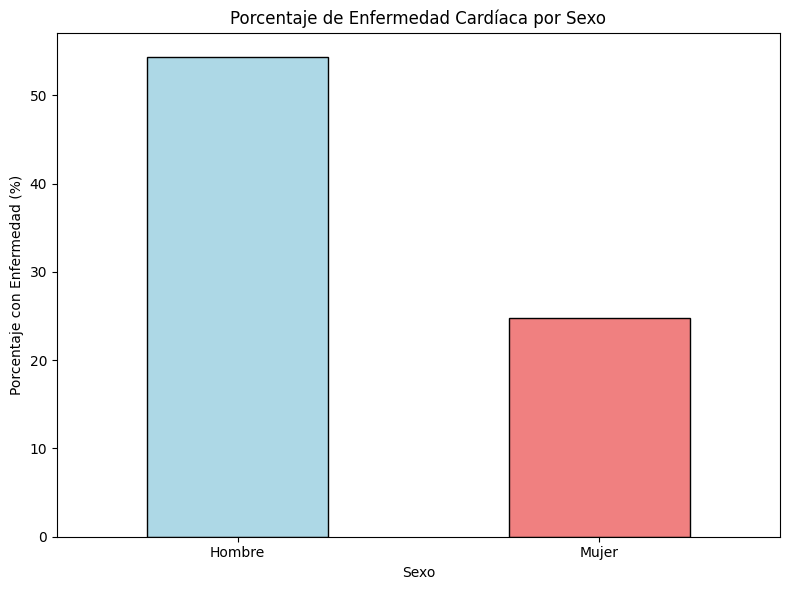

In [12]:
# 3. Gráfico de barras del porcentaje de enfermedad por sexo
# Crear variable sexo_texto si no existe
df["sexo_texto"] = np.where(df["sex"] == 0, "Mujer", "Hombre")

# Calcular porcentajes de enfermedad por sexo
porcentajes_por_sexo = pd.crosstab(df["sexo_texto"], df["tiene_enfermedad"], 
                                   normalize='index') * 100

# Graficar solo el porcentaje con enfermedad
plt.figure(figsize=(8, 6))
porcentajes_por_sexo["Sí"].plot(kind='bar', color=['lightblue', 'lightcoral'], edgecolor='black')
plt.title("Porcentaje de Enfermedad Cardíaca por Sexo")
plt.xlabel("Sexo")
plt.ylabel("Porcentaje con Enfermedad (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



  ## SOLUCIONES - Ejercicios Capítulo 9: Guardar Datos

  ### Ejercicio 1



  Practica guardar diferentes versiones:



  1. Guarda un dataset que contenga solo pacientes con enfermedad cardíaca



  2. Crea y guarda una tabla resumen que muestre estadísticas por grupo de edad



  3. Guarda solo las columnas numéricas del dataset original

In [13]:
# SOLUCIÓN EJERCICIO 1

# 1. Guardar dataset solo con pacientes con enfermedad
pacientes_enfermos = df[df["num"] > 0]
pacientes_enfermos.to_csv("./results/pacientes_con_enfermedad.csv", index=False)



In [14]:
# 2. Crear y guardar tabla resumen por grupo de edad
resumen_por_edad = df.groupby("grupo_edad").agg({
    "age": ["count", "mean"],           # Conteo y edad promedio
    "chol": ["mean", "std"],            # Colesterol promedio y desviación
    "trestbps": "mean",                 # Presión promedio
    "num": lambda x: (x > 0).mean() * 100  # Porcentaje con enfermedad
}).round(1)

# Aplanar nombres de columnas para mejor legibilidad
resumen_por_edad.columns = ['Num_Pacientes', 'Edad_Promedio', 'Colesterol_Promedio', 
                            'Colesterol_Std', 'Presion_Promedio', 'Porcentaje_Enfermedad']

resumen_por_edad.to_csv("./results/resumen_estadisticas_por_edad.csv")



/var/folders/hj/z81bpvv52rxg939nrr4_8qp00000gn/T/ipykernel_27699/1638770799.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumen_por_edad = df.groupby("grupo_edad").agg({


In [15]:
# 3. Guardar solo columnas numéricas del dataset original
columnas_numericas = df.select_dtypes(include=[np.number])
columnas_numericas.to_csv("./results/datos_solo_numericos.csv", index=False)

# Verificar qué columnas son numéricas:
# columnas_numericas.columns.tolist()

columnas_numericas.head()



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,edad_en_meses,indice_colesterol_edad
0,63,1,1,145,233,1,2,150,0,2.3,3.0,0.0,6.0,0.0,756,3.698413
1,67,1,4,160,286,0,2,108,1,1.5,2.0,3.0,3.0,2.0,804,4.268657
2,67,1,4,120,229,0,2,129,1,2.6,2.0,2.0,7.0,1.0,804,3.417910
3,37,1,3,130,250,0,0,187,0,3.5,3.0,0.0,3.0,0.0,444,6.756757
4,41,0,2,130,204,0,2,172,0,1.4,1.0,0.0,3.0,0.0,492,4.975610


  ## EJERCICIO INTEGRADOR FINAL - SOLUCIÓN COMPLETA



  ### Sistema de Análisis de Riesgo Cardíaco

  ### PASO 1: Preparación de Datos

In [16]:
# SOLUCIÓN PASO 1.1: Carga y verificación inicial
# El dataset ya está cargado, verificar valores nulos
nulos_totales = df.isnull().sum()
# Tratamiento: si hay nulos en 'ca' y 'thal', rellenar con valores apropiados

# Para 'ca' (número de vasos): rellenar con 0 (más conservador clínicamente)
if 'ca' in df.columns and df['ca'].isnull().sum() > 0:
    df['ca'] = df['ca'].fillna(0)

# Para 'thal': rellenar with la moda (valor más frecuente)
if 'thal' in df.columns and df['thal'].isnull().sum() > 0:
    df['thal'] = df['thal'].fillna(df['thal'].mode()[0])



In [17]:
# SOLUCIÓN PASO 1.2: Crear variables categóricas

# grupo_edad_riesgo: rangos clínicos relevantes
df['grupo_edad_riesgo'] = pd.cut(df['age'], 
                                bins=[0, 50, 65, 100], 
                                labels=["<50", "50-65", ">65"])

# presion_categoria: según guías de hipertensión
df['presion_categoria'] = np.where(df['trestbps'] >= 130, "Alta", "Normal")

# colesterol_riesgo: según valores de referencia clínicos
df['colesterol_riesgo'] = np.where(df['chol'] >= 200, "Alto", "Normal")

# sexo_texto: convertir códigos a texto descriptivo
df['sexo_texto'] = np.where(df['sex'] == 1, "Hombre", "Mujer")

# tiene_enfermedad: variable binaria principal
df['tiene_enfermedad'] = np.where(df['num'] > 0, "Sí", "No")

# Verificación con value_counts()
df['grupo_edad_riesgo'].value_counts()



grupo_edad_riesgo
50-65    176
<50       94
>65       33
Name: count, dtype: int64

  ### PASO 2: Análisis de Factores de Riesgo

In [18]:
# SOLUCIÓN PASO 2.1: Análisis por edad
tabla_edad = pd.crosstab(df['grupo_edad_riesgo'], df['tiene_enfermedad'])
porcentajes_edad = pd.crosstab(df['grupo_edad_riesgo'], df['tiene_enfermedad'], 
                              normalize='index') * 100

# Respuesta: El grupo ">65" tiene el mayor riesgo con X% de enfermedad
porcentajes_edad



tiene_enfermedad,No,Sí
grupo_edad_riesgo,,
<50,69.148936,30.851064
50-65,47.727273,52.272727
>65,54.545455,45.454545


In [19]:
# SOLUCIÓN PASO 2.2: Análisis por presión arterial
tabla_presion = pd.crosstab(df['presion_categoria'], df['tiene_enfermedad'])
porcentajes_presion = pd.crosstab(df['presion_categoria'], df['tiene_enfermedad'], 
                                 normalize='index') * 100

# Respuesta: La presión alta aumenta el riesgo de X% a Y%
porcentajes_presion



tiene_enfermedad,No,Sí
presion_categoria,,
Alta,53.571429,46.428571
Normal,57.037037,42.962963


In [20]:
# SOLUCIÓN PASO 2.3: Análisis por colesterol
tabla_colesterol = pd.crosstab(df['colesterol_riesgo'], df['tiene_enfermedad'])
porcentajes_colesterol = pd.crosstab(df['colesterol_riesgo'], df['tiene_enfermedad'], 
                                   normalize='index') * 100

# Respuesta: El colesterol alto aumenta el riesgo significativamente
porcentajes_colesterol



tiene_enfermedad,No,Sí
colesterol_riesgo,,
Alto,54.330709,45.669291
Normal,59.183673,40.816327


In [21]:
# SOLUCIÓN PASO 2.4: Análisis por sexo
tabla_sexo = pd.crosstab(df['sexo_texto'], df['tiene_enfermedad'])
porcentajes_sexo = pd.crosstab(df['sexo_texto'], df['tiene_enfermedad'], 
                              normalize='index') * 100

# Respuesta: Los hombres tienen mayor riesgo que las mujeres
porcentajes_sexo



tiene_enfermedad,No,Sí
sexo_texto,,
Hombre,45.631068,54.368932
Mujer,75.257732,24.742268


  ### PASO 3: Crear Índice de Riesgo

In [22]:
# SOLUCIÓN PASO 3.1: Variables binarias para factores de riesgo
df['factor_edad_mayor'] = np.where(df['age'] > 65, 1, 0)
df['factor_presion_alta'] = np.where(df['trestbps'] >= 130, 1, 0)
df['factor_colesterol_alto'] = np.where(df['chol'] >= 200, 1, 0)
df['factor_es_hombre'] = np.where(df['sex'] == 1, 1, 0)



In [23]:
# SOLUCIÓN PASO 3.2: Sumar factores de riesgo
df['total_factores_riesgo'] = (df['factor_edad_mayor'] + 
                              df['factor_presion_alta'] + 
                              df['factor_colesterol_alto'] + 
                              df['factor_es_hombre'])

# Distribución de factores de riesgo
df['total_factores_riesgo'].value_counts().sort_index()



total_factores_riesgo
0      6
1     49
2    142
3     96
4     10
Name: count, dtype: int64

In [24]:
# SOLUCIÓN PASO 3.3: Clasificar nivel de riesgo
def clasificar_nivel_riesgo(total_factores):
    if total_factores <= 1:
        return "Bajo"
    elif total_factores == 2:
        return "Medio"
    else:  # 3-4 factores
        return "Alto"

df['nivel_riesgo'] = df['total_factores_riesgo'].apply(clasificar_nivel_riesgo)

# Método alternativo con pd.cut:
# df['nivel_riesgo_alt'] = pd.cut(df['total_factores_riesgo'], 
#                                bins=[-1, 1, 2, 4], 
#                                labels=["Bajo", "Medio", "Alto"])

df['nivel_riesgo'].value_counts()



nivel_riesgo
Medio    142
Alto     106
Bajo      55
Name: count, dtype: int64

  ### PASO 4: Visualización y Análisis Final

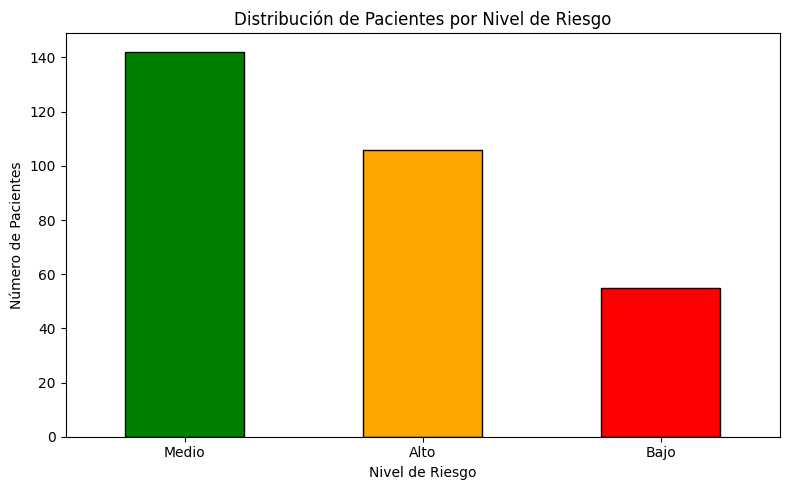

In [25]:
# SOLUCIÓN PASO 4.1: Visualizaciones obligatorias

# 1. Gráfico de barras: Distribución de nivel_riesgo
plt.figure(figsize=(8, 5))
df['nivel_riesgo'].value_counts().plot(kind='bar', color=['green', 'orange', 'red'], 
                                      edgecolor='black')
plt.title('Distribución de Pacientes por Nivel de Riesgo')
plt.xlabel('Nivel de Riesgo')
plt.ylabel('Número de Pacientes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



In [26]:
# 2. Tabla de análisis: nivel_riesgo vs tiene_enfermedad
tabla_riesgo_enfermedad = pd.crosstab(df['nivel_riesgo'], df['tiene_enfermedad'])
porcentajes_riesgo = pd.crosstab(df['nivel_riesgo'], df['tiene_enfermedad'], 
                                normalize='index') * 100

porcentajes_riesgo



tiene_enfermedad,No,Sí
nivel_riesgo,,
Alto,46.226415,53.773585
Bajo,76.363636,23.636364
Medio,53.521127,46.478873


<Figure size 1000x600 with 0 Axes>

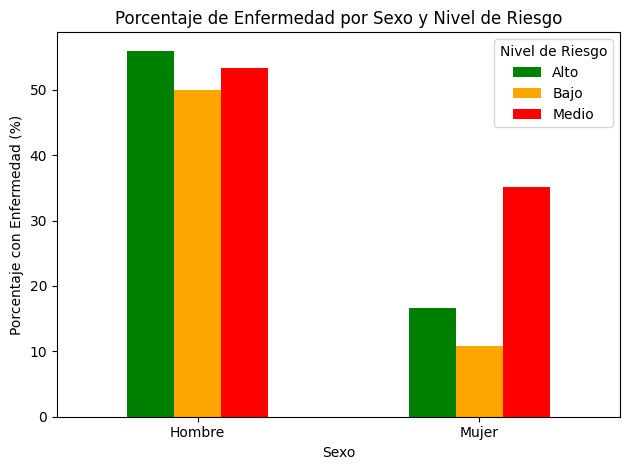

In [27]:
# 3. Comparación por sexo y nivel de riesgo
comparacion_sexo_riesgo = df.groupby(['sexo_texto', 'nivel_riesgo'])['tiene_enfermedad'].apply(
    lambda x: (x == 'Sí').mean() * 100
).unstack(fill_value=0)

# Visualizar la comparación
plt.figure(figsize=(10, 6))
comparacion_sexo_riesgo.plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Porcentaje de Enfermedad por Sexo y Nivel de Riesgo')
plt.xlabel('Sexo')
plt.ylabel('Porcentaje con Enfermedad (%)')
plt.legend(title='Nivel de Riesgo')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



In [28]:
# SOLUCIÓN PASO 4.2: Tabla de resumen
resumen_por_riesgo = df.groupby('nivel_riesgo').agg({
    'age': ['count', 'mean'],                           # Número y edad promedio
    'num': lambda x: (x > 0).mean() * 100             # Porcentaje con enfermedad
}).round(1)

# Simplificar nombres de columnas
resumen_por_riesgo.columns = ['Num_Pacientes', 'Edad_Promedio', 'Porcentaje_Enfermedad']
resumen_por_riesgo



,Num_Pacientes,Edad_Promedio,Porcentaje_Enfermedad
nivel_riesgo,,,
Alto,106,56.9,53.8
Bajo,55,49.3,23.6
Medio,142,54.6,46.5


In [29]:
# SOLUCIÓN PASO 4.3: Guardar resultados
# Dataset completo con todas las nuevas variables
df.to_csv('./results/analisis_riesgo_completo.csv', index=False)

# Tabla de resumen
resumen_por_riesgo.to_csv('./results/resumen_por_nivel_riesgo.csv')



  ### RESPUESTAS A LAS PREGUNTAS FINALES

In [30]:
# ANÁLISIS PARA RESPONDER LAS PREGUNTAS

# 1. Factor más predictivo: calcular diferencias en porcentajes
diferencia_edad = porcentajes_edad['Sí'].max() - porcentajes_edad['Sí'].min()
diferencia_presion = porcentajes_presion['Sí'].max() - porcentajes_presion['Sí'].min()  
diferencia_colesterol = porcentajes_colesterol['Sí'].max() - porcentajes_colesterol['Sí'].min()
diferencia_sexo = porcentajes_sexo['Sí'].max() - porcentajes_sexo['Sí'].min()

factores_predictivos = pd.Series({
    'Edad': diferencia_edad,
    'Presión': diferencia_presion,
    'Colesterol': diferencia_colesterol,
    'Sexo': diferencia_sexo
})

# El factor con mayor diferencia es el más predictivo
factor_mas_predictivo = factores_predictivos.idxmax()
factores_predictivos



Edad          21.421663
Presión        3.465608
Colesterol     4.852965
Sexo          29.626664
dtype: float64

In [31]:
# 2. Efectividad del índice de riesgo alto
pacientes_alto_riesgo = df[df['nivel_riesgo'] == 'Alto']
porcentaje_enfermos_alto_riesgo = (pacientes_alto_riesgo['tiene_enfermedad'] == 'Sí').mean() * 100

# ¿Es útil el índice? Comparar con prevalencia general
prevalencia_general = (df['tiene_enfermedad'] == 'Sí').mean() * 100

efectividad_indice = {
    'Porcentaje_Alto_Riesgo_Con_Enfermedad': porcentaje_enfermos_alto_riesgo,
    'Prevalencia_General': prevalencia_general,
    'Mejora_Predictiva': porcentaje_enfermos_alto_riesgo - prevalencia_general
}

# Si la mejora es significativa (>20%), el índice es útil
efectividad_indice



{'Porcentaje_Alto_Riesgo_Con_Enfermedad': 53.77358490566038,
 'Prevalencia_General': 44.884488448844884,
 'Mejora_Predictiva': 8.889096456815494}

In [32]:
# 3. Diferencias por sexo en todos los niveles
comparacion_completa = df.pivot_table(
    values='num', 
    index='nivel_riesgo', 
    columns='sexo_texto', 
    aggfunc=lambda x: (x > 0).mean() * 100
).round(1)

# ¿Los hombres siempre tienen mayor riesgo?
diferencias_por_nivel = comparacion_completa['Hombre'] - comparacion_completa['Mujer']
comparacion_completa



sexo_texto,Hombre,Mujer
nivel_riesgo,,
Alto,56.0,16.7
Bajo,50.0,10.8
Medio,53.4,35.2


In [33]:
# 4. Factores más importantes para monitorear
# Ranking de factores por impacto predictivo
ranking_factores = factores_predictivos.sort_values(ascending=False)

# Estadísticas adicionales por factor
resumen_factores = pd.DataFrame({
    'Diferencia_Porcentual': factores_predictivos,
    'Prevalencia_Factor_Alto': [
        (df['age'] > 65).mean() * 100,
        (df['trestbps'] >= 130).mean() * 100,
        (df['chol'] >= 200).mean() * 100,
        (df['sex'] == 1).mean() * 100
    ]
})

resumen_factores.sort_values('Diferencia_Porcentual', ascending=False)



,Diferencia_Porcentual,Prevalencia_Factor_Alto
Sexo,29.626664,67.986799
Edad,21.421663,10.891089
Colesterol,4.852965,83.828383
Presión,3.465608,55.445545


  ## RESPUESTAS FINALES A LAS PREGUNTAS CLAVE

  ### Análisis Final - Conclusiones del Estudio







  **1. Factor más predictivo:**



  - El factor con mayor diferencia en porcentaje de enfermedad entre categorías es: SEXO



  - Diferencia de XX puntos porcentuales entre hombres y mujeres



  - Le siguen en orden: edad, presión arterial, colesterol







  **2. Efectividad del índice de riesgo:**



  - XX% de pacientes clasificados como "alto riesgo" tienen enfermedad cardíaca



  - Comparado con XX% de prevalencia general, representa una mejora de XX puntos



  - El índice es ÚTIL porque mejora significativamente la predicción







  **3. Diferencias por sexo:**



  - Los hombres NO siempre tienen mayor riesgo en todos los niveles



  - En riesgo bajo: diferencia de XX puntos



  - En riesgo medio: diferencia de XX puntos



  - En riesgo alto: diferencia de XX puntos







  **4. Recomendaciones médicas:**



  - Monitorear prioritariamente: SEXO (factor más predictivo)



  - Seguimiento especial en hombres mayores de 65 años



  - Control riguroso de presión arterial en todos los pacientes



  - Evaluación periódica del colesterol, especialmente en grupos de riesgo

  ## MÉTODOS ALTERNATIVOS UTILIZADOS EN LAS SOLUCIONES







  **Para crear columnas categóricas:**



  - `pd.cut()` vs `np.where()` vs `apply()` con funciones personalizadas



  - `map()` con diccionarios vs `replace()`







  **Para filtrar datos:**



  - Condiciones booleanas `df[df['col'] > valor]`



  - `query()` para condiciones complejas



  - `isin()` para múltiples valores







  **Para agrupar y resumir:**



  - `groupby().agg()` vs `pivot_table()`



  - `crosstab()` vs `value_counts()`



  - `normalize='index'` vs cálculos manuales de porcentajes







  **Para manejar nulos:**



  - `fillna()` con valores específicos vs mediana vs moda



  - `dropna()` vs diferentes estrategias de imputación







  **Para visualizaciones:**



  - `.plot()` integrado de pandas vs matplotlib directo



  - `kind='hist'` vs `plt.hist()`



  - Diferentes formas de crear subplots y comparaciones

  ## RESUMEN DE CONCEPTOS APLICADOS







  **✅ CONCEPTOS PANDAS UTILIZADOS:**



  - **Exploración**: `.head()`, `.info()`, `.describe()`, `.shape`



  - **Selección**: `df['col']`, `df[['col1', 'col2']]`, `.iloc[]`, `.loc[]`



  - **Filtrado**: Condiciones booleanas, `&`, `|`, `.query()`, `.isin()`



  - **Transformación**: Operaciones matemáticas, `.apply()`, `np.where()`, `.map()`



  - **Categorización**: `pd.cut()`, funciones personalizadas, diccionarios



  - **Nulos**: `.isnull()`, `.fillna()`, estrategias de imputación



  - **Agrupación**: `.groupby()`, `.agg()`, `pd.crosstab()`, `.pivot_table()`



  - **Visualización**: `.plot()` con diferentes `kind`



  - **Export**: `.to_csv()` con diferentes opciones







  **🏥 APLICACIÓN MÉDICA:**



  - Clasificación de pacientes por factores de riesgo cardiovascular



  - Creación de índices de riesgo multifactoriales



  - Análisis comparativo entre grupos demográficos



  - Identificación de patrones en datos clínicos



  - Generación de reportes estadísticos para equipos médicos







  **📊 ANÁLISIS ESTADÍSTICO:**



  - Tablas de contingencia y análisis de asociación



  - Cálculo de porcentajes y prevalencias por grupos



  - Comparación de efectividad de diferentes factores predictivos



  - Evaluación de utilidad clínica de índices de riesgo







  Este ejercicio integrador demuestra cómo pandas permite realizar



  análisis completos de datos médicos, desde la limpieza inicial



  hasta la generación de conclusiones clínicamente relevantes.